<a href="https://colab.research.google.com/github/sheershaagrawal/projectdatamites/blob/master/Monthly_Air_Temperature_Forecasting_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Problem Statement:
Forecast monthly air temperature using historical time series data.

Objective:
Build a machine learning model to predict future temperature trends.

Why Important?

Climate analysis 🌍
Agriculture planning 🌾
Weather forecasting ⛅


IMPORT LIBRARIES


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

CONNECT GOOGLE DRIVE


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


LOAD FILE


In [4]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/PRAICP-1003-AirTempTS.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/data')

print(os.listdir('/content/data'))

['Data']


In [7]:
for root, dirs, files in os.walk('/content/data'):
    for file in files:
        print(file)

Copy of metadata-surface-air-temperature-monthly-mean.txt
surface-air-temperature-monthly-mean.csv


In [9]:
import os

print(os.listdir('/content'))

['.config', 'data', 'drive', 'sample_data']


In [10]:
import zipfile

zip_path = '/content/drive/MyDrive/PRAICP-1003-AirTempTS.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/data')

print("Done extracting")

Done extracting


In [11]:
import os

for root, dirs, files in os.walk('/content'):
    for file in files:
        print(os.path.join(root, file))

/content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
/content/.config/.last_survey_prompt.yaml
/content/.config/active_config
/content/.config/default_configs.db
/content/.config/.last_update_check.json
/content/.config/.last_opt_in_prompt.yaml
/content/.config/config_sentinel
/content/.config/gce
/content/.config/logs/2026.03.23/13.29.47.572748.log
/content/.config/logs/2026.03.23/13.29.34.829749.log
/content/.config/logs/2026.03.23/13.29.36.176357.log
/content/.config/logs/2026.03.23/13.29.24.904753.log
/content/.config/logs/2026.03.23/13.29.46.856905.log
/content/.config/logs/2026.03.23/13.29.02.727930.log
/content/.config/configurations/config_default
/content/data/Data/Copy of metadata-surface-air-temperature-monthly-mean.txt
/content/data/Data/surface-air-temperature-monthly-mean.csv
/content/drive/MyDrive/Getting started.pdf
/content/drive/MyDrive/xcc-vtpm-gqc – 14 Jun 2021.pdf
/content/drive/MyDrive/EM answersheet by sheersha agrawal mid sem 01ug20020

LOAD CSV


In [12]:
import pandas as pd

df = pd.read_csv('/content/data/Data/surface-air-temperature-monthly-mean.csv')

. Data Understanding (Theory)

Features:

Month → Time index
Mean_temp → Target variable

DATA PRE-PROCESSING


In [14]:
print(df.columns)

Index(['month', 'mean_temp'], dtype='object')


In [15]:
df['month'] = pd.to_datetime(df['month'])
df.set_index('month', inplace=True)
df = df.sort_index()

df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 462 entries, 1982-01-01 to 2020-06-01
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   mean_temp  462 non-null    float64
dtypes: float64(1)
memory usage: 7.2 KB


Exploratory Data Analysis (EDA)
📊 Trend Visualization

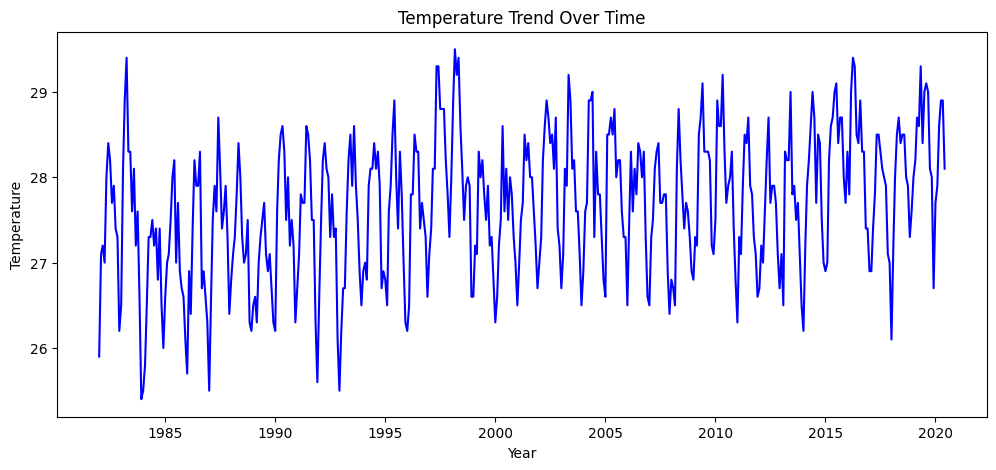

In [17]:
plt.figure(figsize=(12,5))
plt.plot(df['mean_temp'], color='blue')
plt.title("Temperature Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Temperature")
plt.show()

Train-Test Split


In [18]:
train_size = int(len(df)*0.8)
train = df[:train_size]
test = df[train_size:]

Model 1: ARIMA (Baseline)
📘 Theory:

ARIMA captures:

Trend (I)
Past values (AR)
Errors (MA)

In [20]:
arima_model = ARIMA(train['mean_temp'], order=(5,1,0))
arima_fit = arima_model.fit()

print(arima_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:              mean_temp   No. Observations:                  369
Model:                 ARIMA(5, 1, 0)   Log Likelihood                -321.565
Date:                Thu, 26 Mar 2026   AIC                            655.131
Time:                        12:55:28   BIC                            678.579
Sample:                    01-01-1982   HQIC                           664.447
                         - 09-01-2012                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0437      0.056     -0.786      0.432      -0.153       0.065
ar.L2         -0.0019      0.056     -0.033      0.974      -0.112       0.108
ar.L3         -0.1118      0.052     -2.138      0.0

ARIMA Forecast

In [21]:
arima_pred = arima_fit.forecast(steps=len(test))

Model Evaluation

In [23]:
rmse_arima = np.sqrt(mean_squared_error(test['mean_temp'], arima_pred))
print("ARIMA RMSE:", rmse_arima)

ARIMA RMSE: 0.757091178772054


Model 2: SARIMA
📘 Theory:

SARIMA handles seasonality → perfect for temperature data

In [25]:
sarima_model = SARIMAX(train['mean_temp'],
                      order=(1,1,1),
                      seasonal_order=(1,1,1,12))

sarima_fit = sarima_model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


SARIMA Forecast

In [26]:
sarima_pred = sarima_fit.forecast(steps=len(test))

Evaluate SARIMA

In [28]:
rmse_sarima = np.sqrt(mean_squared_error(test['mean_temp'], sarima_pred))
print("SARIMA RMSE:", rmse_sarima)

SARIMA RMSE: 0.6371942473222861


Compare Models 📊

In [29]:
print("ARIMA RMSE:", rmse_arima)
print("SARIMA RMSE:", rmse_sarima)

ARIMA RMSE: 0.757091178772054
SARIMA RMSE: 0.6371942473222861


Visualization

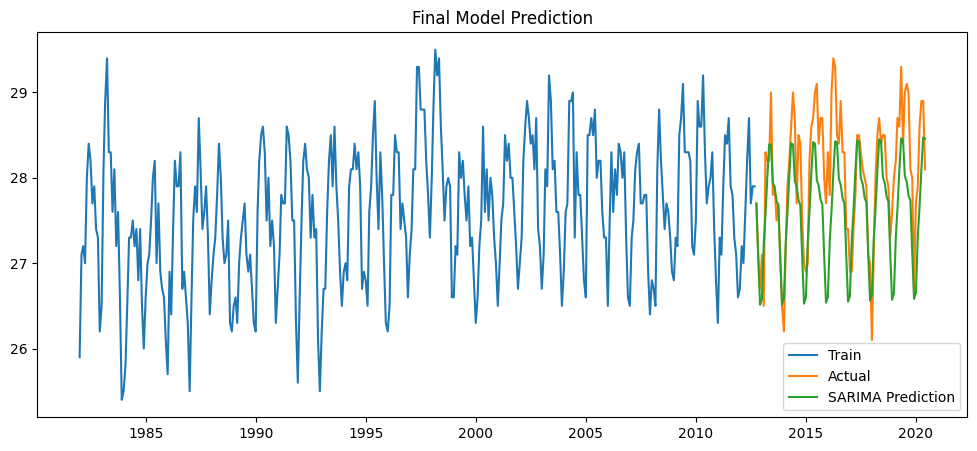

In [31]:
plt.figure(figsize=(12,5))

plt.plot(train.index, train['mean_temp'], label='Train')
plt.plot(test.index, test['mean_temp'], label='Actual')
plt.plot(test.index, sarima_pred, label='SARIMA Prediction')

plt.legend()
plt.title("Final Model Prediction")
plt.show()

Future Prediction

In [32]:
future_forecast = sarima_fit.forecast(steps=12)

print("Future Predictions:")
print(future_forecast)

Future Predictions:
2012-10-01    27.700024
2012-11-01    27.059602
2012-12-01    26.512059
2013-01-01    26.578246
2013-02-01    27.233689
2013-03-01    27.554253
2013-04-01    28.009938
2013-05-01    28.388981
2013-06-01    28.389985
2013-07-01    27.945743
2013-08-01    27.886230
2013-09-01    27.730530
Freq: MS, Name: predicted_mean, dtype: float64
